Environment

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, pearsonr
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units

In [2]:
def inner_predict_loop(noise_type, noise_seeds, image, sigma, scans):
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    image: object
        image that we are adding noise to and then predicting on, ie like the frames object below
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    
    Returns
    -------
    array
        returns array with predictions for all neurons
    
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    scans = ensure_2d_list(scans)
    num_neurons = get_neuron_units(scans)
    num_frames = image.shape[0]

    noise_results = np.empty((noise_seeds, num_frames, num_neurons))

    for noise_i in range(noise_seeds):
                    
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')
        for pair in scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 being chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [91]:
# PLOTS FOR FIRST IMAGE IN 3D RESPONSES OBJECT/STACK
def plot_select30_hist(array, title, neurons, color = 'b'):
    neuron_pvalue = pd.DataFrame({
    'neuron' : [],
    'p_value' :[]
    })

    fig, axes = plt.subplots(5,6, figsize = (20,6))

    array = array[0] # 3d array is going to be inputted, for now just take first image

    p_values = np.empty((neurons.size))
    test_statistics = np.empty((neurons.size))
    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = array[:,neuron]
        ax.hist(plot, color = color)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{round(x,3)}"))

        # hypothesis test
        p_value, test_statistic = shapiro(plot)
        p_values[id] = p_value
        test_statistics[id] = test_statistic
        neuron_pvalue.loc[id] = neuron, p_value

    # display histogram
    fig.suptitle(f"Neuron Outputs: {title}")
    fig.supxlabel('Predicted Firing Rate')
    fig.supylabel('Counts')
    plt.tight_layout()
    plt.show()

    # print dataframe with p values
    neuron_pvalue['neuron'] = neuron_pvalue['neuron'].astype(int)
    neuron_pvalue['p_value'] = neuron_pvalue['p_value'].round(3)
    print(neuron_pvalue)


#### imagenet - EDA

In [24]:
imagenet_path = "C://Users//joshf//Downloads//imagenet-mini"

In [25]:
# use train data for now

train_path = imagenet_path + "//train"

files = [file for file in os.listdir(train_path)]

In [26]:
len(files)

1000

In [27]:
files[0]

'n01440764'

In [28]:
test_file = train_path + '//n01440764'
files = os.listdir(test_file)

In [29]:
len(files)

34

In [30]:
opened_file = Image.open(str(test_file + '//n01440764_6206.JPEG'))

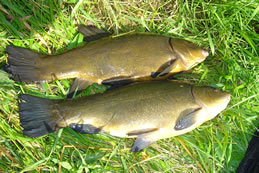

In [31]:
opened_file

In [32]:
opened_file.size

(259, 173)

(259, 173)


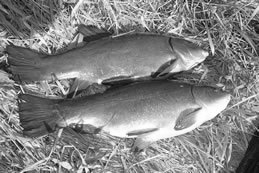

In [33]:
opened_file = opened_file.convert('L') # grayscale
print(opened_file.size)
opened_file

In [34]:
if opened_file.size != (256, 144):
    opened_file = opened_file.resize((256,144))
opened_file.size

(256, 144)

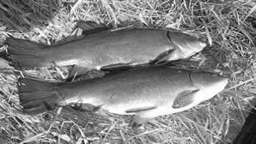

In [35]:
opened_file

In [36]:
opened_file = np.array(opened_file)
opened_file.shape

(144, 256)

In [37]:
opened_file

array([[ 66,  77,  96, ..., 149, 128, 132],
       [ 39,  67,  76, ..., 107, 110,  95],
       [ 57,  58,  62, ..., 173, 164, 123],
       ...,
       [ 98,  86,  94, ...,  26,  23,  19],
       [ 96, 109, 119, ...,  22,  20,  18],
       [104, 102, 111, ...,  21,  20,  19]], dtype=uint8)

In [38]:
opened_file_stack = np.stack([opened_file]*15, axis = 0)
opened_file_stack.shape

(15, 144, 256)

In [44]:
np.unique(opened_file_stack[0] == opened_file_stack[1], return_counts = True)

(array([ True]), array([36864]))

#### imagenet - predictions

In [45]:
# for now assign to x random images
def random_images(num, train = True, path = os.path.join("//imagenet-mini")):
    """
    NOTE: directory structure for subfolers as follows
    --imagenet-mini
        -->train
            -->folder1
                -->picture1-1
                -->picture2-1.....
            -->folder2...
            -->folder3...
                -->picture1-3
                -->pictuer2-3
                -->picture....
        -->validation


    Parameters
    ----------
    num: int
        number of images 
    frames: int
        number of frames
    train: bool
        using training or validation set, defaults to train
    path: string
        defaults to cwd for training folder, otherwise path to train/val. folders needed

    Returns
    -------
    folder_id
        folder # used
    image_ids
        image #'s used
    np.stack(final_array)
        stack of num DIFFERENT images in one object, shape (num, 144, 256)
    """

    if train == True: train_val = '//train' 
    else: train_val = '//val'

    folder_path = path + train_val # get path to train/val folders
    initial_folders = os.listdir(folder_path)

    folder_id = np.random.randint(0, len(initial_folders) - 1) # get path to random folder within train/val
    image_folder_path = folder_path + '//' + initial_folders[folder_id]

    image_folder = os.listdir(image_folder_path) # path to folder in train/val with images

    image_ids = np.random.randint(0,len(image_folder) - 1, size = num)
    final_array = np.empty(shape = (num, 144, 256))

    for i in range(num):
        image_name = '//' + image_folder[i]
        image_path = image_folder_path + image_name
        image = Image.open(image_path)
        image = image.convert('L')
        if image.size != (256, 144): image = image.resize((256, 144))
        image = np.array(image)
        final_array[i] = image

    return folder_id, image_ids, np.stack(final_array, axis = 0)


In [51]:
folder_id, image_ids, image_stack = random_images(1, path = "C://Users//joshf//Downloads//imagenet-mini")

In [52]:
image_stack.shape

(1, 144, 256)

#### predicting on five random images from previous section

In [5]:
def predict_loop(noise_type, noise_seeds, images, sigma, scans, num_frames = 30): 
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    images: object
        images (usually object from np.stack()) that we are adding noise to and then predicting on
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    num_frames: int
        number of frames per image, defaults to 30
    
    Returns
    -------
    stack_sum
        array with predictions for each image, noise_seed, and neuron
    mean_array
        returns array with each mean neuron prediction for all images entered
    var_array
        returns array with each var. in neuron prediction for all images entered
        
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    final_array = np.empty(shape = (len(images), noise_seeds, num_frames, get_neuron_units(scans)))

    for i, element in enumerate(images):
        predict_stack = np.stack([images[i]] * num_frames, axis = 0)

        prediction1 = inner_predict_loop(noise_type, noise_seeds, predict_stack, sigma, scans)  # shape is (noise_seeds, frames, neurons)

        try:
            if (prediction_stack.shape != prediction1.shape): 
                prediction1 = np.reshape(prediction1, (1, prediction1.shape[0], prediction1.shape[1], prediction1.shape[2]))
                prediction_stack = np.stack((prediction1, prediction_stack), axis = 0)
        except NameError:
            prediction_stack = prediction1
        
        final_array[i] = prediction_stack
        del prediction_stack

    #final_stack = np.stack(final_array, axis = 0)
    final_stack_sum = np.sum(final_array, axis = 2)

    return final_stack_sum, np.mean(final_stack_sum, axis = 1), np.var(final_stack_sum, axis = 1)
            

In [98]:
# note: we are using 10 noise seeds here and 5 frames of each image

# dynamic
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 10, image_stack, 3, [[4,7]], num_frames = 5)
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 10, image_stack, 15, [[4,7]], num_frames = 5)
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 10, image_stack, 30, [[4,7]], num_frames = 5)

# constant
constant3, constant3_mean, constant3_var = predict_loop("constant", 10, image_stack, 3, [[4,7]], num_frames = 5)
constant15, constant15_mean, constant15_var = predict_loop("constant", 10, image_stack, 15, [[4,7]], num_frames = 5)
constant30, constant30_mean, constant30_var = predict_loop("constant", 10, image_stack, 30, [[4,7]], num_frames = 5)

In [76]:
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 100, image_stack, 3, [[4,7]], num_frames = 10)

In [77]:
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 100, image_stack, 15, [[4,7]], num_frames = 10)

In [79]:
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 100, image_stack, 30, [[4,7]], num_frames = 10)

In [80]:
constant3, constant3_mean, constant3_var = predict_loop('constant', 100, image_stack, 3, [[4,7]], num_frames = 10)

In [81]:
constant15, constant15_mean, constant15_var = predict_loop('constant', 100, image_stack, 15, [[4,7]], num_frames = 10)

In [82]:
constant30, constant30_mean, constant30_var = predict_loop('constant', 100, image_stack, 30, [[4,7]], num_frames = 10)

#### visualizations - 1 image

In [83]:
neurons = np.random.randint(0, np.max(7493), size = 30)
print('random neurons: ', neurons)

random neurons:  [1685  368 1571  670 1918 1231 6795 6492 2507 1444 2361 6699 6672 6790
 6209 6699 1447 5583 2237 2161 7217 5114 4321 4823 6822 5935  823 6501
 6819 5782]


random neurons:  [1685  368 1571  670 1918 1231 6795 6492 2507 1444 2361 6699 6672 6790
 6209 6699 1447 5583 2237 2161 7217 5114 4321 4823 6822 5935  823 6501
 6819 5782]

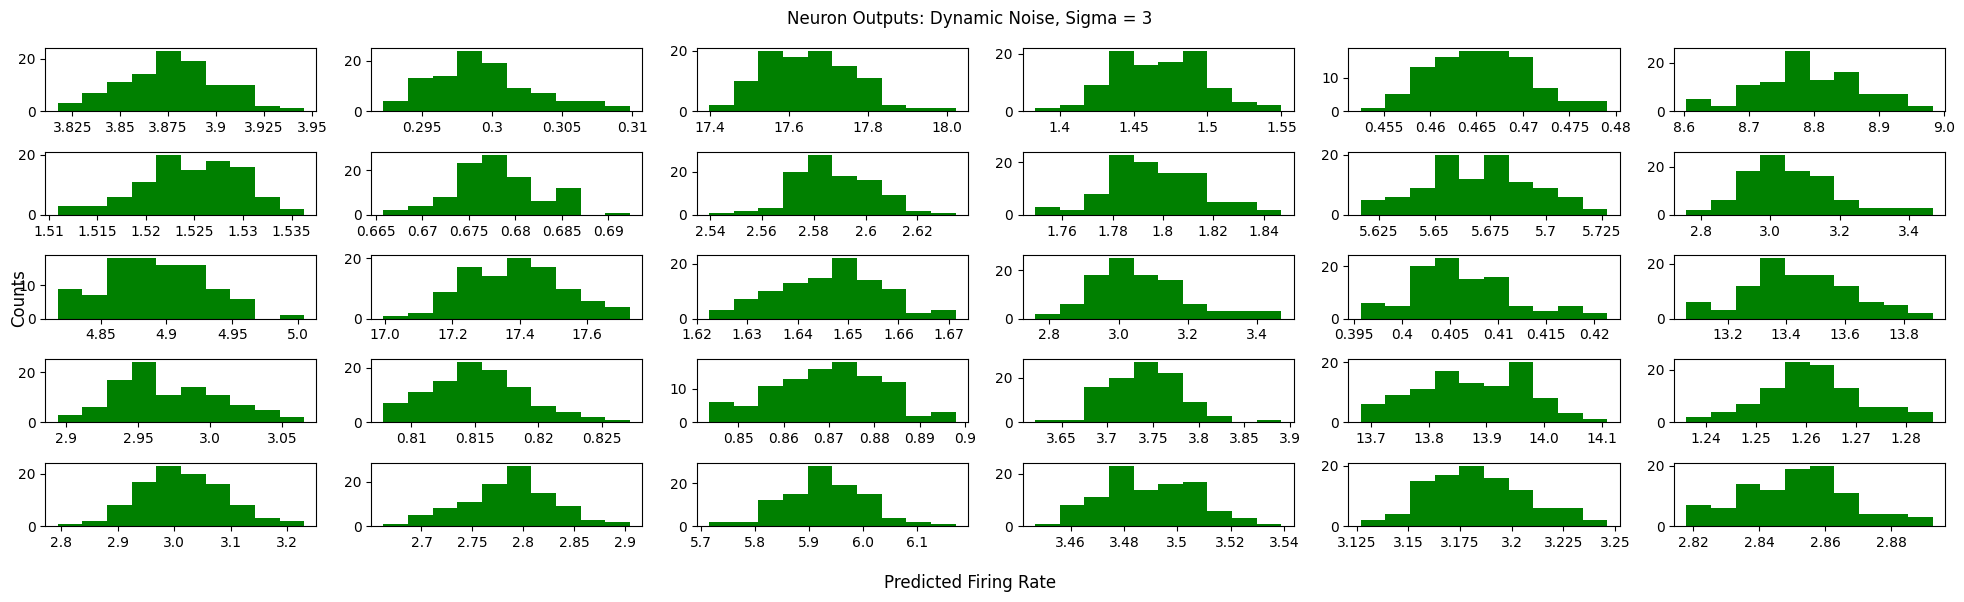

    neuron  p_value
0     1685    0.994
1      368    0.968
2     1571    0.989
3      670    0.993
4     1918    0.994
5     1231    0.992
6     6795    0.989
7     6492    0.983
8     2507    0.976
9     1444    0.991
10    2361    0.992
11    6699    0.963
12    6672    0.987
13    6790    0.993
14    6209    0.991
15    6699    0.963
16    1447    0.976
17    5583    0.991
18    2237    0.974
19    2161    0.987
20    7217    0.986
21    5114    0.981
22    4321    0.982
23    4823    0.992
24    6822    0.992
25    5935    0.990
26     823    0.988
27    6501    0.986
28    6819    0.989
29    5782    0.988


In [92]:
plot_select30_hist(dynamic3, "Dynamic Noise, Sigma = 3", neurons, color = 'g')

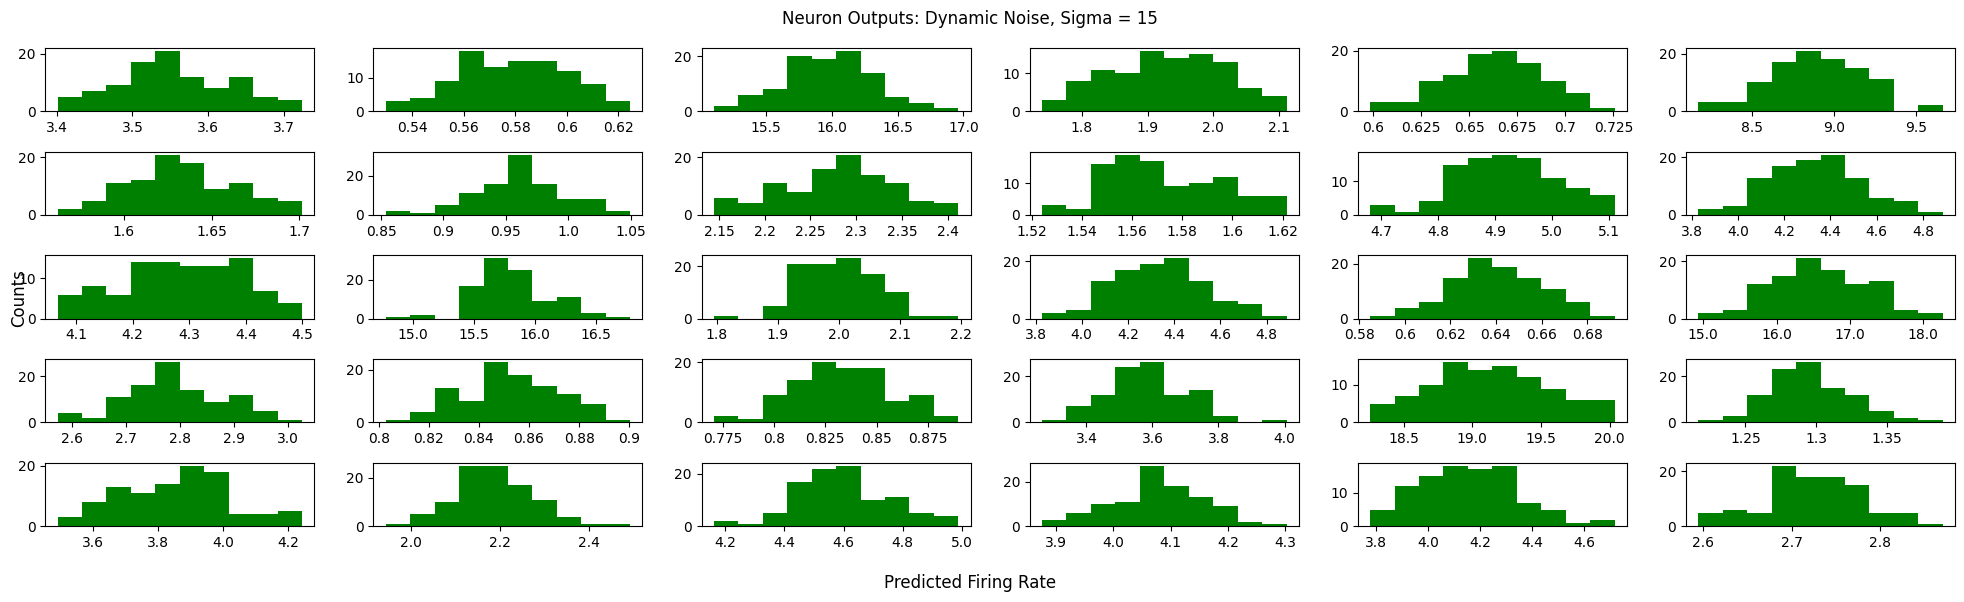

    neuron  p_value
0     1685    0.986
1      368    0.985
2     1571    0.995
3      670    0.982
4     1918    0.993
5     1231    0.995
6     6795    0.989
7     6492    0.984
8     2507    0.990
9     1444    0.969
10    2361    0.987
11    6699    0.992
12    6672    0.982
13    6790    0.972
14    6209    0.987
15    6699    0.992
16    1447    0.996
17    5583    0.994
18    2237    0.986
19    2161    0.994
20    7217    0.992
21    5114    0.987
22    4321    0.985
23    4823    0.986
24    6822    0.984
25    5935    0.988
26     823    0.991
27    6501    0.992
28    6819    0.987
29    5782    0.993


In [93]:
plot_select30_hist(dynamic15, "Dynamic Noise, Sigma = 15", neurons, color = 'g')

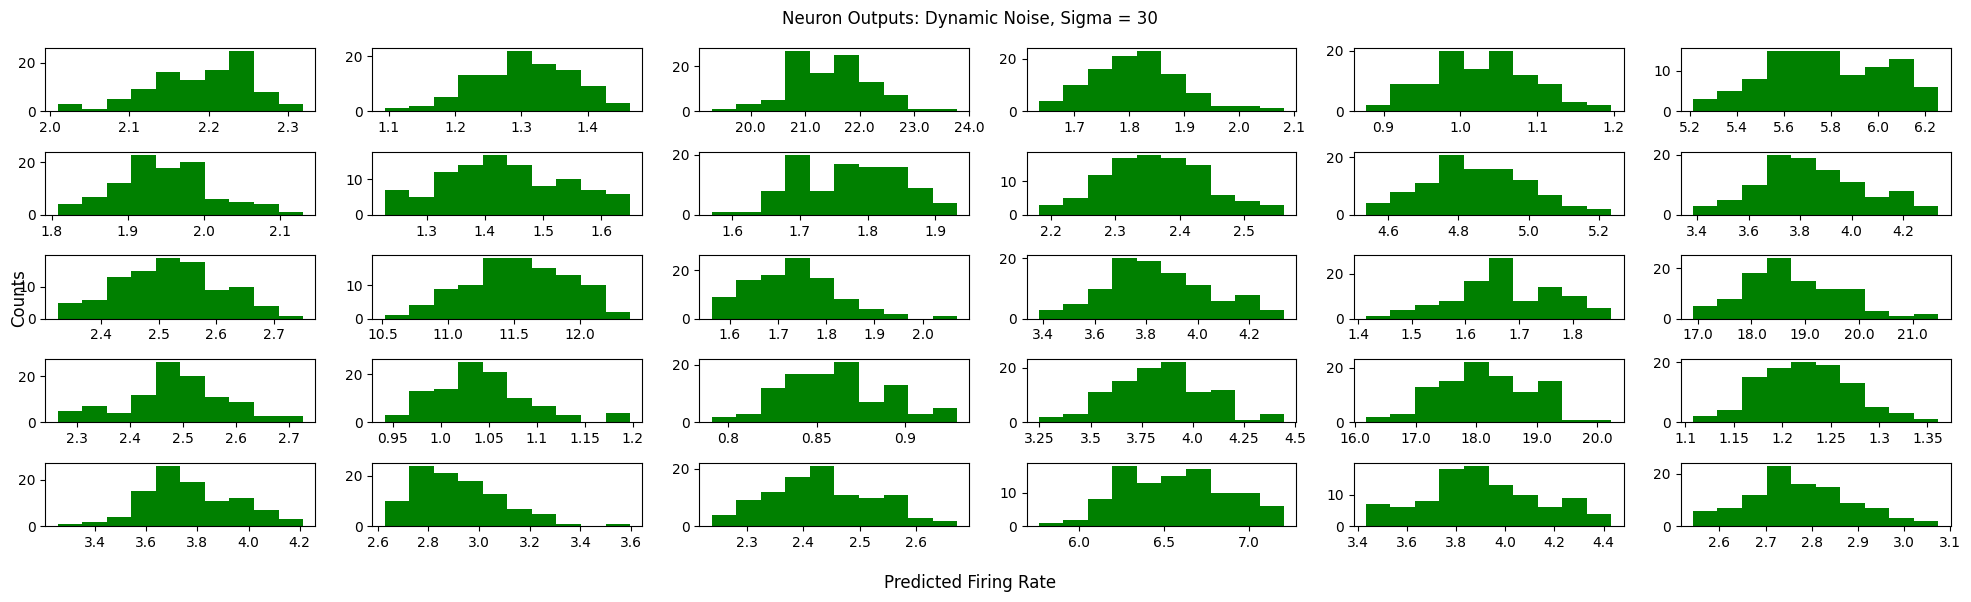

    neuron  p_value
0     1685    0.969
1      368    0.991
2     1571    0.989
3      670    0.984
4     1918    0.993
5     1231    0.978
6     6795    0.987
7     6492    0.982
8     2507    0.983
9     1444    0.994
10    2361    0.992
11    6699    0.984
12    6672    0.992
13    6790    0.989
14    6209    0.968
15    6699    0.984
16    1447    0.986
17    5583    0.980
18    2237    0.988
19    2161    0.958
20    7217    0.986
21    5114    0.994
22    4321    0.990
23    4823    0.992
24    6822    0.989
25    5935    0.950
26     823    0.987
27    6501    0.980
28    6819    0.984
29    5782    0.986


In [94]:
plot_select30_hist(dynamic30, "Dynamic Noise, Sigma = 30", neurons, color = 'g')

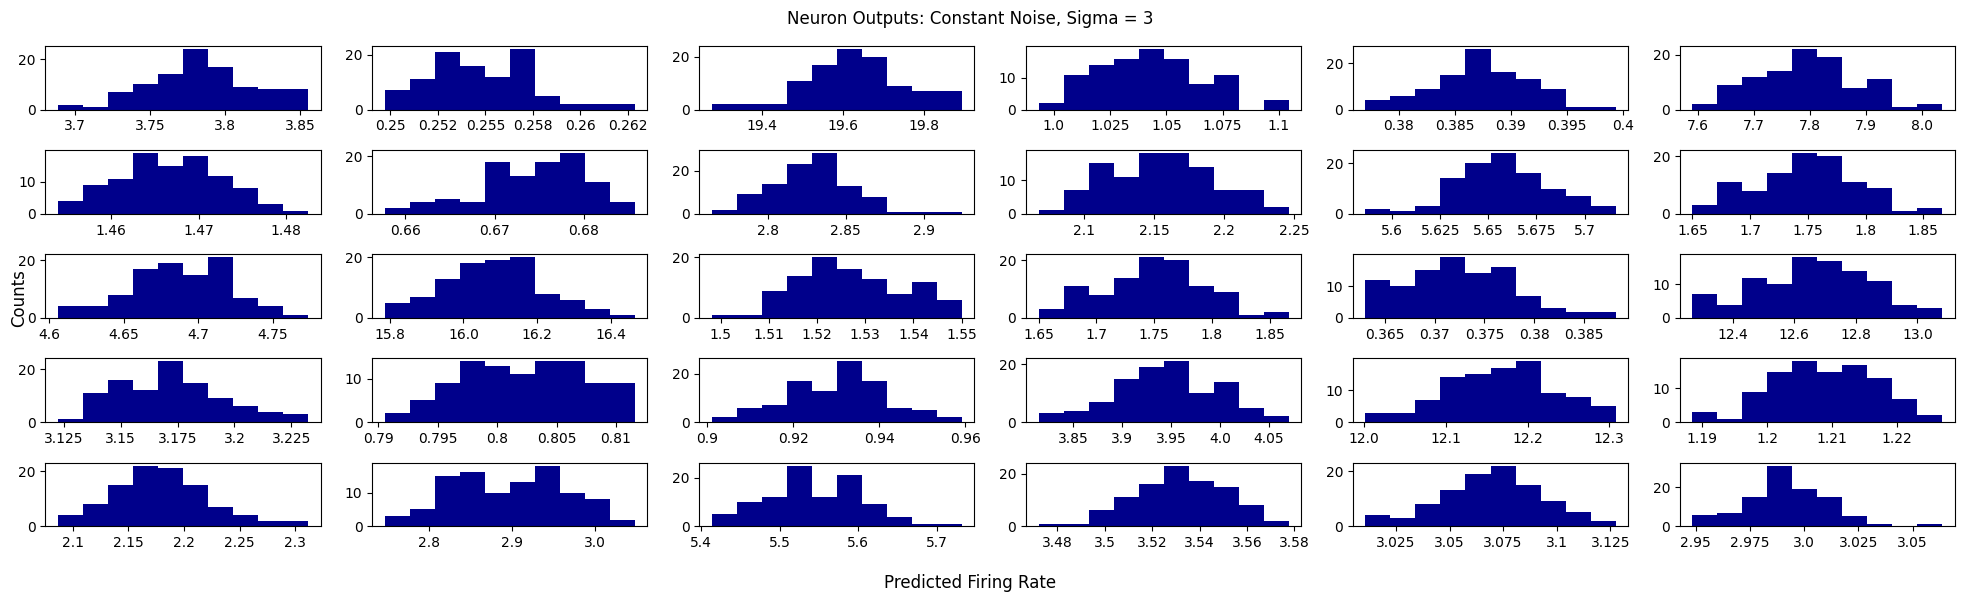

    neuron  p_value
0     1685    0.985
1      368    0.979
2     1571    0.983
3      670    0.987
4     1918    0.991
5     1231    0.992
6     6795    0.989
7     6492    0.974
8     2507    0.982
9     1444    0.988
10    2361    0.986
11    6699    0.991
12    6672    0.991
13    6790    0.994
14    6209    0.974
15    6699    0.991
16    1447    0.980
17    5583    0.986
18    2237    0.978
19    2161    0.980
20    7217    0.990
21    5114    0.993
22    4321    0.990
23    4823    0.991
24    6822    0.984
25    5935    0.981
26     823    0.990
27    6501    0.992
28    6819    0.992
29    5782    0.980


In [97]:
plot_select30_hist(constant3, "Constant Noise, Sigma = 3", neurons, 'darkblue')

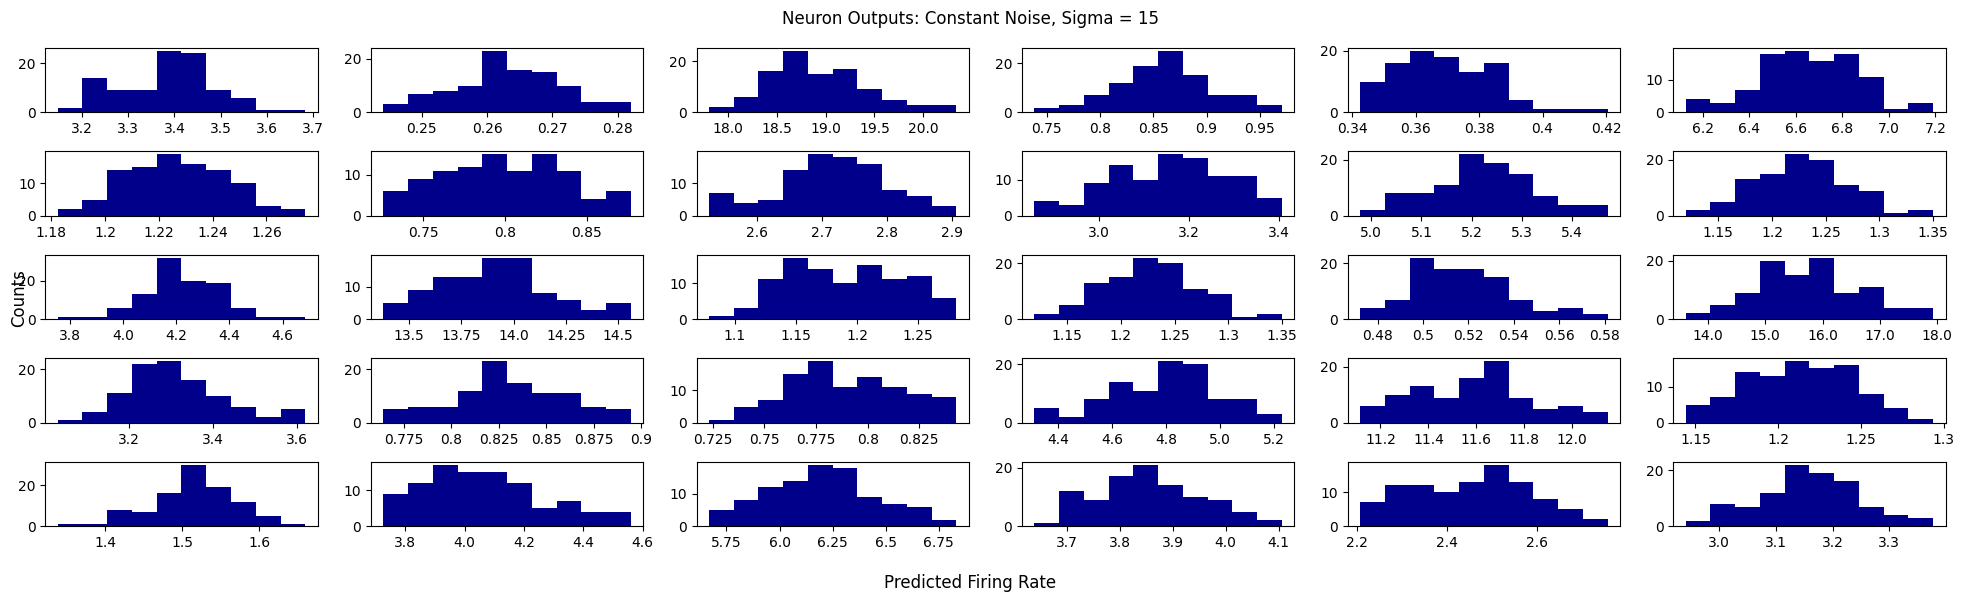

    neuron  p_value
0     1685    0.971
1      368    0.992
2     1571    0.979
3      670    0.995
4     1918    0.974
5     1231    0.985
6     6795    0.995
7     6492    0.981
8     2507    0.985
9     1444    0.985
10    2361    0.991
11    6699    0.995
12    6672    0.985
13    6790    0.980
14    6209    0.968
15    6699    0.995
16    1447    0.983
17    5583    0.989
18    2237    0.973
19    2161    0.987
20    7217    0.983
21    5114    0.989
22    4321    0.981
23    4823    0.988
24    6822    0.986
25    5935    0.967
26     823    0.991
27    6501    0.984
28    6819    0.981
29    5782    0.990


In [98]:
plot_select30_hist(constant15, "Constant Noise, Sigma = 15", neurons, 'darkblue')

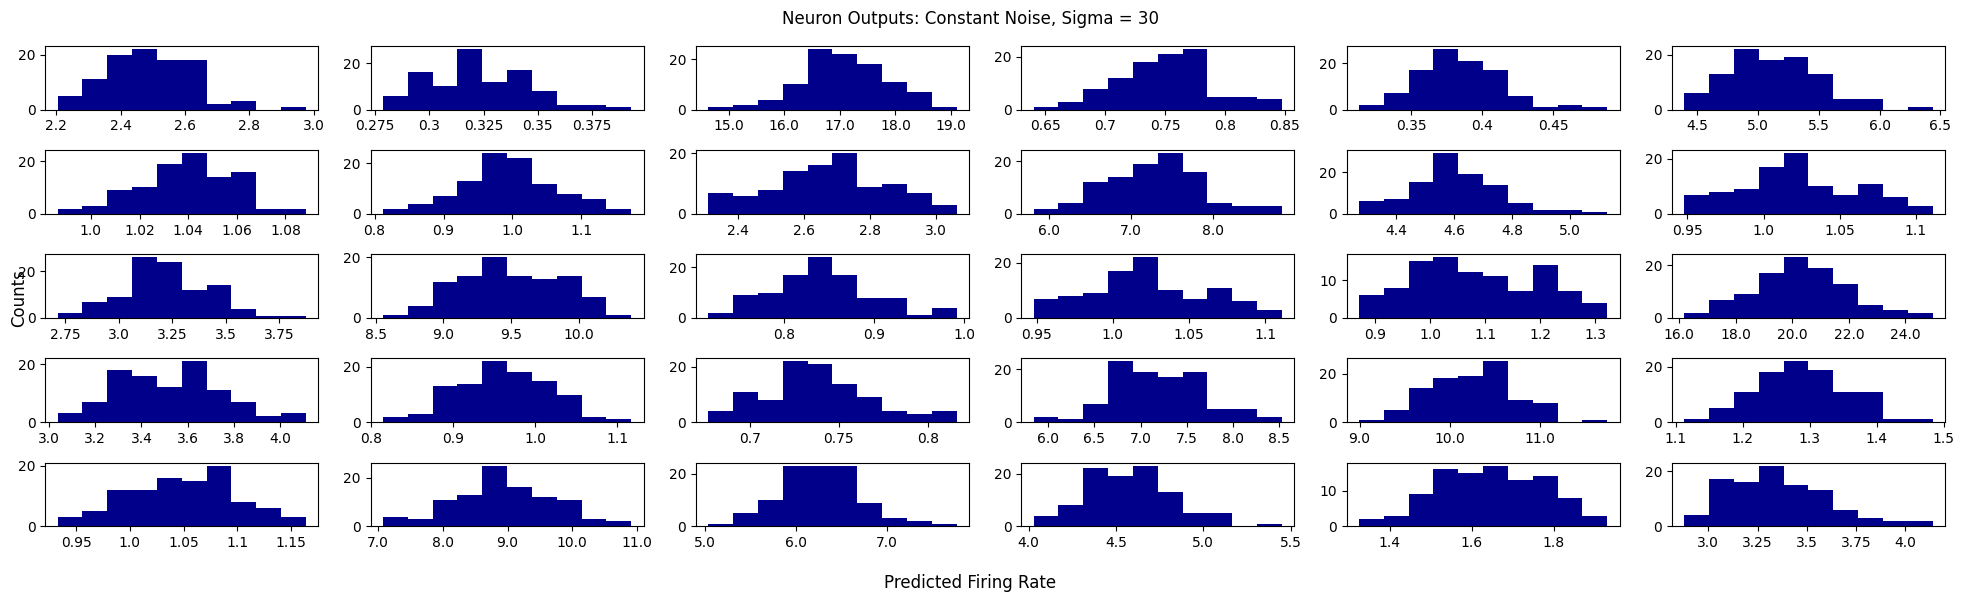

    neuron  p_value
0     1685    0.978
1      368    0.980
2     1571    0.993
3      670    0.993
4     1918    0.980
5     1231    0.983
6     6795    0.989
7     6492    0.993
8     2507    0.986
9     1444    0.992
10    2361    0.982
11    6699    0.982
12    6672    0.989
13    6790    0.981
14    6209    0.985
15    6699    0.982
16    1447    0.976
17    5583    0.993
18    2237    0.984
19    2161    0.995
20    7217    0.983
21    5114    0.992
22    4321    0.992
23    4823    0.991
24    6822    0.990
25    5935    0.994
26     823    0.991
27    6501    0.979
28    6819    0.990
29    5782    0.975


In [99]:
plot_select30_hist(constant30, "Constant Noise, Sigma = 30", neurons, 'darkblue')